Using device : cuda
Fine-tuning  : up to 20 epochs, patience=5
✓ HAM10000 baseline backbone loaded — 320 tensors copied, 0 skipped
  branch1 and branch2 are randomly initialized
  Total parameters: 23,624,277

Dataset size: 10015 images
Train: 8012 | Val: 2003
Train batches: 126 | Val batches: 32

FINE-TUNING — BranchyNet on HAM10000 (from baseline)
Epoch  1/20 | Loss: 1.1818 | Train: 0.9933 | Val: 0.8957 <- best saved
Epoch  2/20 | Loss: 1.1312 | Train: 0.9939 | Val: 0.8937 (no improve 1/5)
Epoch  3/20 | Loss: 1.0922 | Train: 0.9948 | Val: 0.8967 <- best saved
Epoch  4/20 | Loss: 1.0697 | Train: 0.9948 | Val: 0.8937 (no improve 1/5)
Epoch  5/20 | Loss: 1.0481 | Train: 0.9963 | Val: 0.8932 (no improve 2/5)
Epoch  6/20 | Loss: 1.0348 | Train: 0.9949 | Val: 0.8917 (no improve 3/5)
Epoch  7/20 | Loss: 1.0159 | Train: 0.9946 | Val: 0.8917 (no improve 4/5)
Epoch  8/20 | Loss: 1.0061 | Train: 0.9954 | Val: 0.8912 (no improve 5/5)

Early stopping triggered at epoch 8

Best validation accuracy

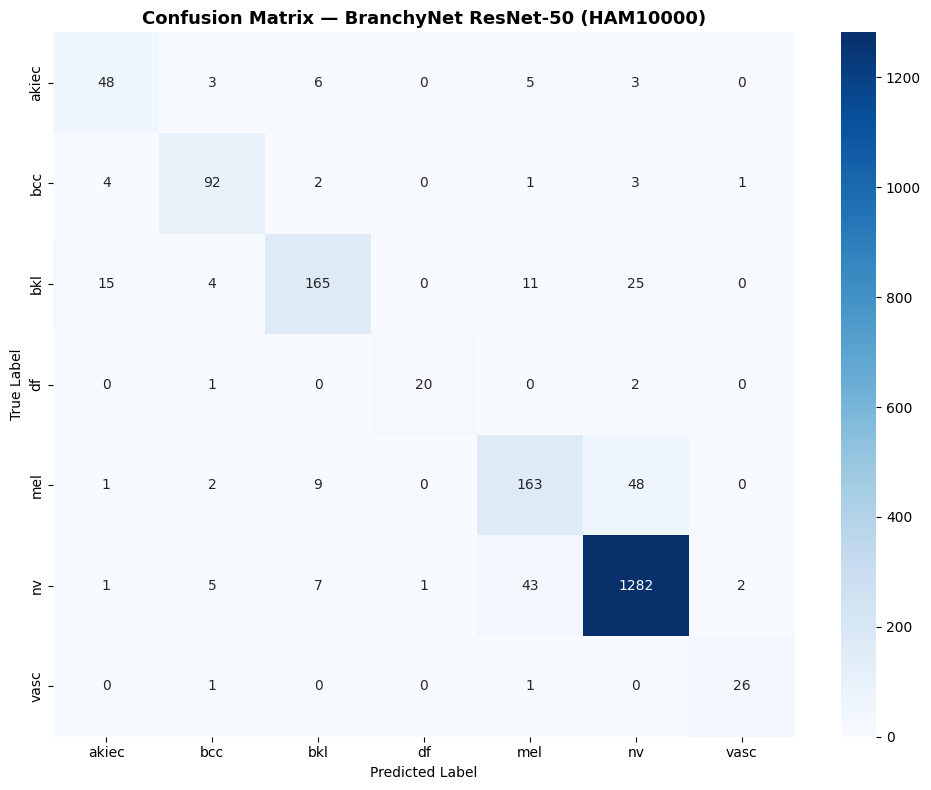


ADAPTIVE COMPUTATION — Threshold Sweep
  τ=0.50 | Acc=0.8902 | F1=0.8142 | Exit1=17.1% Exit2=14.5% Exit3=68.3% | Time=6.7262ms/sample
  τ=0.60 | Acc=0.8952 | F1=0.8350 | Exit1=4.6% Exit2=16.4% Exit3=79.0% | Time=7.0405ms/sample
  τ=0.70 | Acc=0.8962 | F1=0.8397 | Exit1=0.3% Exit2=4.4% Exit3=95.3% | Time=7.0362ms/sample
  τ=0.80 | Acc=0.8967 | F1=0.8420 | Exit1=0.0% Exit2=0.0% Exit3=100.0% | Time=7.1092ms/sample
  τ=0.90 | Acc=0.8967 | F1=0.8420 | Exit1=0.0% Exit2=0.0% Exit3=100.0% | Time=7.1005ms/sample
  τ=0.95 | Acc=0.8967 | F1=0.8420 | Exit1=0.0% Exit2=0.0% Exit3=100.0% | Time=7.0860ms/sample

MODEL COMPLEXITY METRICS
  Parameters               : 23,624,277
  Model size               : 90.4359 MB
  FLOPs (full)             : 8.1745 G
  Inference (single, full) : 13.359 ms
  Inference (batch128)     : 2655.19 ms (48.2 img/s)
  Inference (τ=0.8 adapt)  : 15.812 ms

✓ Metrics saved → __ham10000__branchynet_metrics.json

COMPARISON: Baseline vs BranchyNet
  (baseline JSON not found at 

In [1]:
# ============================================================
# BranchyNet — ResNet-50 on HAM10000
# FINE-TUNING from baseline: __ham10000__baseline_resnet50.pth
# ============================================================

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import time, os, json, random, tempfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ── CONFIG ────────────────────────────────────────────────────
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 64
EPOCHS        = 20         # fine-tuning — backbone already converged
LR            = 1e-3       # lower LR — backbone needs gentle updates
PATIENCE      = 5          # tighter early stopping for fine-tuning
NUM_CLASSES   = 7
IMG_SIZE      = 224
VAL_SPLIT     = 0.2
BASELINE_PATH = "../__ham10000__baseline_resnet50.pth"
SAVE_PATH     = "__ham10000__branchynet_resnet50.pth"

DATA_ROOT = "../ham10000"
CSV_PATH  = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")
IMG_DIR   = os.path.join(DATA_ROOT, "images")

EXIT_THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
BRANCH_WEIGHTS  = [0.2, 0.3, 0.5]

HAM10000_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
HAM10000_CLASS_NAMES = {
    "akiec": "Actinic Keratoses",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevi",
    "vasc":  "Vascular Lesions",
}
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

print(f"Using device : {DEVICE}")
print(f"Fine-tuning  : up to {EPOCHS} epochs, patience={PATIENCE}")

# ── UTILITY FUNCTIONS ─────────────────────────────────────────
def disk_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".pth", delete=False) as f:
        tmp = f.name
    try:
        torch.save(model.state_dict(), tmp)
        size = os.path.getsize(tmp) / 1024 ** 2
    finally:
        os.remove(tmp)
    return round(size, 4)

def measure_inference(model, device, img_size=224, batch_size=128,
                      runs_single=500, runs_batch=100):
    model.eval()
    use_cuda = device.type == "cuda"
    dummy_single = torch.randn(1, 3, img_size, img_size, device=device)
    dummy_batch  = torch.randn(batch_size, 3, img_size, img_size, device=device)

    with torch.no_grad():
        for _ in range(50):
            model(dummy_single)
    if use_cuda:
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(runs_single):
            if use_cuda:
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(dummy_single)
            if use_cuda:
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    inf_ms_single = np.mean(times) * 1000

    with torch.no_grad():
        for _ in range(10):
            model(dummy_batch)
    if use_cuda:
        torch.cuda.synchronize()
    if use_cuda:
        start_ev = torch.cuda.Event(enable_timing=True)
        end_ev   = torch.cuda.Event(enable_timing=True)
        batch_times = []
        with torch.no_grad():
            for _ in range(runs_batch):
                start_ev.record()
                model(dummy_batch)
                end_ev.record()
                torch.cuda.synchronize()
                batch_times.append(start_ev.elapsed_time(end_ev))
        inf_ms_batch = np.mean(batch_times)
    else:
        batch_times = []
        with torch.no_grad():
            for _ in range(runs_batch):
                t0 = time.perf_counter()
                model(dummy_batch)
                batch_times.append((time.perf_counter() - t0) * 1000)
        inf_ms_batch = np.mean(batch_times)

    return {
        "single_img_ms"      : round(inf_ms_single, 4),
        "batch128_ms"        : round(inf_ms_batch, 4),
        "per_img_ms"         : round(inf_ms_batch / batch_size, 4),
        "throughput_imgs_sec": round(batch_size / (inf_ms_batch / 1000), 1),
        "timing_method"      : "sync+perf_counter (single), CUDA events (batch)",
    }

def measure_adaptive_inference(model, device, threshold=0.8,
                                img_size=224, runs=500):
    model.eval()
    use_cuda = device.type == "cuda"
    dummy = torch.randn(1, 3, img_size, img_size, device=device)
    with torch.no_grad():
        for _ in range(50):
            model.adaptive_forward(dummy, threshold=threshold)
    if use_cuda:
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(runs):
            if use_cuda:
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            model.adaptive_forward(dummy, threshold=threshold)
            if use_cuda:
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    return round(np.mean(times) * 1000, 4)

def compute_flops(model, device, input_size=(1, 3, 224, 224)):
    m = model.eval().to(device)
    total_flops = [0]
    hooks = []
    def conv_hook(module, inp, out):
        N, C_out, H_out, W_out = out.shape
        C_in = module.in_channels
        kH, kW = module.kernel_size if isinstance(module.kernel_size, tuple) \
                  else (module.kernel_size, module.kernel_size)
        total_flops[0] += 2 * N * C_out * H_out * W_out * (C_in // module.groups) * kH * kW
    def linear_hook(module, inp, out):
        total_flops[0] += 2 * inp[0].shape[0] * module.in_features * module.out_features
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d):
            hooks.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear):
            hooks.append(mod.register_forward_hook(linear_hook))
    with torch.no_grad():
        m(torch.randn(*input_size, device=device))
    for h in hooks:
        h.remove()
    return round(total_flops[0] / 1e9, 6)

# ── DATASET ───────────────────────────────────────────────────
class HAM10000Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None, class_list=HAM10000_CLASSES):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.class2idx = {cls: i for i, cls in enumerate(class_list)}
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")
        label    = self.class2idx[row["dx"]]
        if self.transform:
            image = self.transform(image)
        return image, label

# ── AUXILIARY BRANCH ──────────────────────────────────────────
class EarlyExitBranch(nn.Module):
    def __init__(self, input_channels, num_classes=NUM_CLASSES):
        super().__init__()
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(input_channels),
            nn.Linear(input_channels, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.branch(x)

# ── BRANCHYNET MODEL ──────────────────────────────────────────
class BranchyResNet50(nn.Module):
    """
    Standard ImageNet stem (7x7 + maxpool) — HAM10000 uses 224x224.
    Backbone loaded from trained HAM10000 baseline.
    branch1 and branch2 are randomly initialized and trained during fine-tuning.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = models.resnet50(weights=None)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)

        self.num_classes = num_classes
        self.stem    = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool
        self.fc      = backbone.fc
        self.branch1 = EarlyExitBranch(256, num_classes)
        self.branch2 = EarlyExitBranch(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x);  logits1 = self.branch1(x)
        x = self.layer2(x);  logits2 = self.branch2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)
        return logits1, logits2, logits3

    @torch.no_grad()
    def adaptive_forward(self, x, threshold=0.8):
        B      = x.size(0)
        device = x.device
        final_logits     = torch.zeros(B, self.num_classes, device=device)
        exit_idx         = torch.full((B,), 2, dtype=torch.long, device=device)
        remaining_global = torch.arange(B, device=device)

        x = self.stem(x)
        x = self.layer1(x)
        logits1 = self.branch1(x)
        conf1   = torch.softmax(logits1, dim=1).max(dim=1).values
        done1   = conf1 >= threshold
        if done1.any():
            g_idx = remaining_global[done1]
            final_logits[g_idx] = logits1[done1]
            exit_idx[g_idx]     = 0
        keep = ~done1
        if not keep.any():
            return final_logits, exit_idx
        x                = x[keep]
        remaining_global = remaining_global[keep]

        x = self.layer2(x)
        logits2 = self.branch2(x)
        conf2   = torch.softmax(logits2, dim=1).max(dim=1).values
        done2   = conf2 >= threshold
        if done2.any():
            g_idx = remaining_global[done2]
            final_logits[g_idx] = logits2[done2]
            exit_idx[g_idx]     = 1
        keep = ~done2
        if not keep.any():
            return final_logits, exit_idx
        x                = x[keep]
        remaining_global = remaining_global[keep]

        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)
        final_logits[remaining_global] = logits3
        return final_logits, exit_idx

# ── BUILD MODEL AND LOAD BASELINE WEIGHTS ─────────────────────
model = BranchyResNet50(num_classes=NUM_CLASSES).to(DEVICE)

baseline_state = torch.load(BASELINE_PATH, map_location=DEVICE)
own_state = model.state_dict()
loaded, skipped = 0, 0
for k, v in baseline_state.items():
    # HAM10000 baseline uses standard stem — remap to BranchyNet's stem.X
    if   k == "conv1.weight":            rk = "stem.0.weight"
    elif k == "bn1.weight":              rk = "stem.1.weight"
    elif k == "bn1.bias":                rk = "stem.1.bias"
    elif k == "bn1.running_mean":        rk = "stem.1.running_mean"
    elif k == "bn1.running_var":         rk = "stem.1.running_var"
    elif k == "bn1.num_batches_tracked": rk = "stem.1.num_batches_tracked"
    else:                                rk = k
    if rk in own_state:
        own_state[rk].copy_(v)
        loaded += 1
    else:
        skipped += 1

model.load_state_dict(own_state)
print(f"✓ HAM10000 baseline backbone loaded — {loaded} tensors copied, {skipped} skipped")
print(f"  branch1 and branch2 are randomly initialized")

total_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_params:,}")

# ── DATA ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].drop_duplicates(subset="image_id").reset_index(drop=True)

print(f"\nDataset size: {len(df)} images")
train_df, val_df = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED, stratify=df["dx"]
)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class2idx      = {cls: i for i, cls in enumerate(HAM10000_CLASSES)}
train_labels   = train_df["dx"].map(class2idx).values
class_counts_  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / (class_counts_ + 1e-6)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_labels),
    replacement=True,
    generator=g,
)

train_set = HAM10000Dataset(train_df, IMG_DIR, transform=transform_train)
val_set   = HAM10000Dataset(val_df,   IMG_DIR, transform=transform_val)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0,
                          worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          worker_init_fn=seed_worker)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── LOSS & OPTIMIZER ──────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                             momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

def branchynet_loss(logits_list, labels, weights=BRANCH_WEIGHTS):
    return sum(w * criterion(l, labels) for w, l in zip(weights, logits_list))

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits1, logits2, logits3 = model(inputs)
        loss = branchynet_loss([logits1, logits2, logits3], labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += logits3.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate_standard(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            _, _, logits3 = model(inputs)
            correct += logits3.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total

# ── TRAINING LOOP ─────────────────────────────────────────────
best_val_acc = 0.0
no_improve   = 0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*60)
print("FINE-TUNING — BranchyNet on HAM10000 (from baseline)")
print("="*60)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_acc         = evaluate_standard(model, val_loader)
    scheduler.step(val_acc)

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        no_improve = 0
        marker = " <- best saved"
    else:
        no_improve += 1
        marker = f" (no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy (final exit): {best_val_acc:.4f}")

# ── FULL EVALUATION ───────────────────────────────────────────
print("\n" + "="*60)
print("FULL EVALUATION — final exit only")
print("="*60)

model = BranchyResNet50(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        _, _, logits3 = model(inputs)
        all_preds.extend(logits3.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=HAM10000_CLASSES, digits=4))

# ── CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=HAM10000_CLASSES, yticklabels=HAM10000_CLASSES)
plt.title("Confusion Matrix — BranchyNet ResNet-50 (HAM10000)", fontsize=13, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("__ham10000__branchynet_confusion_matrix.png", dpi=150)
plt.show()

# ── ADAPTIVE THRESHOLD SWEEP ──────────────────────────────────
print("\n" + "="*60)
print("ADAPTIVE COMPUTATION — Threshold Sweep")
print("="*60)

adaptive_results = []
for tau in EXIT_THRESHOLDS:
    preds_list, labels_list, exit_idx_list = [], [], []
    t_start = time.time()
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            logits, exit_idx = model.adaptive_forward(inputs, threshold=tau)
            preds_list.extend(logits.argmax(1).cpu().numpy())
            labels_list.extend(labels.numpy())
            exit_idx_list.extend(exit_idx.cpu().numpy())
    t_end = time.time()

    preds_arr    = np.array(preds_list)
    labels_arr   = np.array(labels_list)
    exit_idx_arr = np.array(exit_idx_list)
    n            = len(labels_arr)

    acc_t  = accuracy_score(labels_arr, preds_arr)
    prec_t = precision_score(labels_arr, preds_arr, average="macro", zero_division=0)
    rec_t  = recall_score(labels_arr, preds_arr, average="macro", zero_division=0)
    f1_t   = f1_score(labels_arr, preds_arr, average="macro", zero_division=0)

    frac_exit1  = (exit_idx_arr == 0).mean()
    frac_exit2  = (exit_idx_arr == 1).mean()
    frac_exit3  = (exit_idx_arr == 2).mean()
    avg_time_ms = (t_end - t_start) / n * 1000

    adaptive_results.append({
        "threshold"  : tau,
        "accuracy"   : round(acc_t,  6),
        "precision"  : round(prec_t, 6),
        "recall"     : round(rec_t,  6),
        "f1"         : round(f1_t,   6),
        "frac_exit1" : round(frac_exit1, 4),
        "frac_exit2" : round(frac_exit2, 4),
        "frac_exit3" : round(frac_exit3, 4),
        "avg_time_ms": round(avg_time_ms, 4),
    })
    print(f"  τ={tau:.2f} | Acc={acc_t:.4f} | F1={f1_t:.4f} | "
          f"Exit1={frac_exit1:.1%} Exit2={frac_exit2:.1%} Exit3={frac_exit3:.1%} | "
          f"Time={avg_time_ms:.4f}ms/sample")

best_adaptive = max(adaptive_results, key=lambda r: r["accuracy"])

# ── MODEL COMPLEXITY ──────────────────────────────────────────
print("\n" + "="*60)
print("MODEL COMPLEXITY METRICS")
print("="*60)

flops_g      = compute_flops(model, DEVICE, input_size=(1, 3, IMG_SIZE, IMG_SIZE))
infer        = measure_inference(model, DEVICE, img_size=IMG_SIZE)
size_mb      = disk_size_mb(model)
inf_ms_adapt = measure_adaptive_inference(model, DEVICE, threshold=0.8, img_size=IMG_SIZE)

print(f"  Parameters               : {total_params:,}")
print(f"  Model size               : {size_mb:.4f} MB")
print(f"  FLOPs (full)             : {flops_g:.4f} G")
print(f"  Inference (single, full) : {infer['single_img_ms']:.3f} ms")
print(f"  Inference (batch128)     : {infer['batch128_ms']:.2f} ms "
      f"({infer['throughput_imgs_sec']:.1f} img/s)")
print(f"  Inference (τ=0.8 adapt)  : {inf_ms_adapt:.3f} ms")

# ── SAVE METRICS JSON ─────────────────────────────────────────
branchynet_metrics = {
    "accuracy"  : acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "params"    : total_params,
    "size_mb"   : size_mb,
    "flops_G"   : flops_g,
    "inference_ms": {
        "gpu": {
            "single_img_ms"      : infer["single_img_ms"],
            "batch128_ms"        : infer["batch128_ms"],
            "per_img_ms"         : infer["per_img_ms"],
            "throughput_imgs_sec": infer["throughput_imgs_sec"],
            "timing_method"      : infer["timing_method"],
        }
    },
    "method"                      : "early_exit",
    "variant"                     : "BranchyNet_ResNet50",
    "dataset"                     : "HAM10000",
    "training_mode"               : "fine_tuning_from_baseline",
    "baseline_path"               : BASELINE_PATH,
    "epochs"                      : EPOCHS,
    "lr"                          : LR,
    "branch_weights"              : BRANCH_WEIGHTS,
    "num_exits"                   : 3,
    "exit_positions"              : ["after layer1 (256ch)",
                                     "after layer2 (512ch)",
                                     "final fc (2048ch)"],
    "exit_thresholds_tested"      : EXIT_THRESHOLDS,
    "inference_ms_adaptive_tau08" : inf_ms_adapt,
    "adaptive_threshold_results"  : adaptive_results,
    "best_adaptive_result"        : best_adaptive,
    "saved_model_path"            : os.path.abspath(SAVE_PATH),
}

with open("__ham10000__branchynet_metrics.json", "w") as f:
    json.dump(branchynet_metrics, f, indent=2)
print("\n✓ Metrics saved → __ham10000__branchynet_metrics.json")

# ── COMPARISON SUMMARY ────────────────────────────────────────
print("\n" + "="*60)
print("COMPARISON: Baseline vs BranchyNet")
print("="*60)

baseline_json = "__ham10000__baseline_metrics.json"
if os.path.exists(baseline_json):
    with open(baseline_json) as f:
        base = json.load(f)
    scalar_keys = ["accuracy", "precision", "recall", "f1", "params", "size_mb", "flops_G"]
    print(f"\n  {'Metric':<22} {'Baseline':>12} {'BranchyNet':>12} {'Δ':>10}")
    print("  " + "-"*58)
    for k in scalar_keys:
        bv = base.get(k, float("nan"))
        mv = branchynet_metrics.get(k, float("nan"))
        if not isinstance(bv, (int, float)) or not isinstance(mv, (int, float)):
            continue
        delta = mv - bv
        sign  = "+" if delta > 0 else ""
        if k == "params":
            print(f"  {k:<22} {bv:>12,} {mv:>12,} {sign}{delta:>9,.0f}")
        else:
            print(f"  {k:<22} {bv:>12.4f} {mv:>12.4f} {sign}{delta:>9.4f}")
    base_single = base.get("inference_ms", {}).get("gpu", {}).get("single_img_ms", float("nan"))
    full_ms     = infer["single_img_ms"]
    print(f"\n  Inference (single, GPU, full) : {full_ms:.3f} ms  (baseline: {base_single:.3f} ms)")
    print(f"  Inference (τ=0.8 adaptive)    : {inf_ms_adapt:.3f} ms "
          f"({(1 - inf_ms_adapt/full_ms)*100:+.1f}% vs full)")
    print(f"\n  Best adaptive (τ={best_adaptive['threshold']}):")
    print(f"    Accuracy : {best_adaptive['accuracy']:.4f}")
    print(f"    Exit1    : {best_adaptive['frac_exit1']:.1%}")
    print(f"    Exit2    : {best_adaptive['frac_exit2']:.1%}")
    print(f"    Exit3    : {best_adaptive['frac_exit3']:.1%}")
else:
    print(f"  (baseline JSON not found at {baseline_json})")

# ── CHECKPOINT ────────────────────────────────────────────────
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "model_name"    : "BranchyResNet50_HAM10000_finetuned",
        "num_classes"   : NUM_CLASSES,
        "input_size"    : [3, IMG_SIZE, IMG_SIZE],
        "num_exits"     : 3,
        "branch_weights": BRANCH_WEIGHTS,
        "training_mode" : "fine_tuning_from_baseline",
        "normalization" : {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    },
    "classes"    : HAM10000_CLASSES,
    "class_names": HAM10000_CLASS_NAMES,
}, "__ham10000__branchynet_checkpoint.pth")

print("\n" + "="*60)
print("BRANCHYNET HAM10000 FINE-TUNING — COMPLETE")
print("="*60)
print(f"  Weights    → {SAVE_PATH}")
print(f"  Checkpoint → __ham10000__branchynet_checkpoint.pth")
print(f"  Metrics    → __ham10000__branchynet_metrics.json")